# IMPORT LIBRARIES

In [70]:
# PLOTTING & DATA STUFF
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import joblib

# NN
from sklearn.linear_model import Perceptron
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import kerastuner as kt

# ML GENERAL
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# IMBAL LEARNING
from imblearn.over_sampling import SMOTE


# HELPERS
from utils import backup_dataframe, load_latest_backup


# LOAD CSV

In [2]:
pd.set_option('display.max_colwidth', None)  # Show full content in columns
pd.set_option('display.max_rows', None)

In [3]:
df = pd.read_csv("dataset/train_post_outlier.csv")

# FAST CHECK AND PROCESS

In [4]:
df.shape

(129663, 70)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129663 entries, 0 to 129662
Data columns (total 70 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   129663 non-null  int64  
 1   runtimeMinutes               129663 non-null  float64
 2   awardWins                    129663 non-null  float64
 3   numVotes                     129663 non-null  float64
 4   totalCredits                 129663 non-null  float64
 5   awardNominationsExcludeWins  129663 non-null  float64
 6   canHaveEpisodes              129663 non-null  int64  
 7   isAdult                      129663 non-null  int64  
 8   numRegions                   129663 non-null  float64
 9   userReviewsTotal             129663 non-null  float64
 10  countryOfOrigin              129663 non-null  object 
 11  genres                       129663 non-null  object 
 12  castNumber                   129663 non-null  float64
 13 

In [7]:
df = df.drop(columns = "Unnamed: 0")

In [18]:
cols_to_drop = ['countryOfOrigin', 'genres', 'soundMixes', 'continent', 'filtered_genres', 'filtered_soundMixes']
df = df.drop(columns = cols_to_drop)

# SPLIT

In [ ]:

X = df.drop(columns=['rating_class', 'averageRating']) 
y = df['rating_class']  # 🎯 Target variabile


In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [85]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(103730, 62) (25933, 62) (103730,) (25933,)


# PERCEPTRON

In [ ]:
# Inizializza il Perceptron
perceptron = Perceptron(random_state=42)

# Fit sui dati
perceptron.fit(X_train, y_train)


Perceptron(random_state=42)

In [23]:
y_pred_perceptron = perceptron.predict(X_test)

In [24]:
print("=== Perceptron Report ===")
print(classification_report(y_test, y_pred_perceptron))

=== Perceptron Report ===
              precision    recall  f1-score   support

           0       0.14      0.03      0.04       911
           1       0.11      0.09      0.10      1615
           2       0.22      0.16      0.19      3761
           3       0.28      0.23      0.26      6804
           4       0.38      0.39      0.39      8363
           5       0.13      0.23      0.17      3761
           6       0.07      0.06      0.06       718

    accuracy                           0.25     25933
   macro avg       0.19      0.17      0.17     25933
weighted avg       0.26      0.25      0.25     25933



# MLP

In [27]:
#!pip install tensorflow

In [46]:
X_train.shape[1]

61

## SIMPLE NN 61-120-7 
OPT: ADAM <BR>
BATCH: 32 <BR>
REG: NO <BR>
MOM: NO <BR>
EARLY STOPPING: NO <BR>

In [47]:
# 1. Definiamo la rete di base
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # Input layer
    layers.Dense(120, activation='relu'),     # 1 hidden layer
    layers.Dense(len(np.unique(y_train)), activation='softmax')  # Output layer
])

# 2. Compila il modello§
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Allena il modello
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # userà 20% dei dati per validation interna
    epochs=50,
    batch_size=32,
    verbose=2
)

# 4. Valutazione su Test Set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# 5. Predizioni
y_pred_prob = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# 6. Report di classificazione
print("=== MLP Keras Report ===")
print(classification_report(y_test, y_pred_classes))


Epoch 1/50
2594/2594 - 5s - 2ms/step - accuracy: 0.3776 - loss: 1.5365 - val_accuracy: 0.3901 - val_loss: 1.4884
Epoch 2/50
2594/2594 - 2s - 827us/step - accuracy: 0.3967 - loss: 1.4671 - val_accuracy: 0.3941 - val_loss: 1.4589
Epoch 3/50
2594/2594 - 3s - 1ms/step - accuracy: 0.4046 - loss: 1.4430 - val_accuracy: 0.3979 - val_loss: 1.4627
Epoch 4/50
2594/2594 - 3s - 1ms/step - accuracy: 0.4086 - loss: 1.4274 - val_accuracy: 0.4060 - val_loss: 1.4299
Epoch 5/50
2594/2594 - 2s - 940us/step - accuracy: 0.4115 - loss: 1.4177 - val_accuracy: 0.3989 - val_loss: 1.4347
Epoch 6/50
2594/2594 - 10s - 4ms/step - accuracy: 0.4158 - loss: 1.4092 - val_accuracy: 0.4047 - val_loss: 1.4264
Epoch 7/50
2594/2594 - 7s - 3ms/step - accuracy: 0.4161 - loss: 1.4019 - val_accuracy: 0.4048 - val_loss: 1.4322
Epoch 8/50
2594/2594 - 3s - 977us/step - accuracy: 0.4201 - loss: 1.3944 - val_accuracy: 0.4073 - val_loss: 1.4254
Epoch 9/50
2594/2594 - 2s - 809us/step - accuracy: 0.4219 - loss: 1.3895 - val_accuracy: 

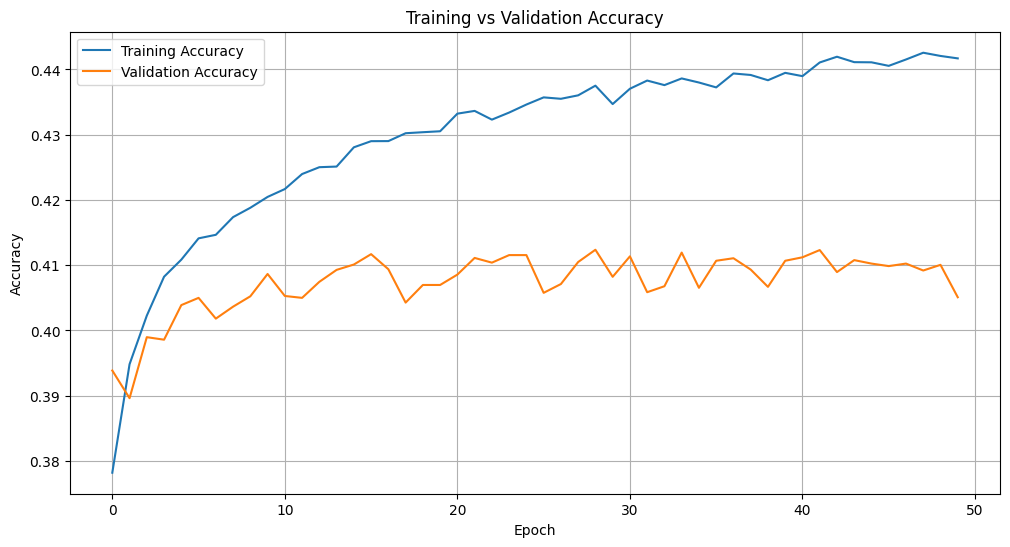

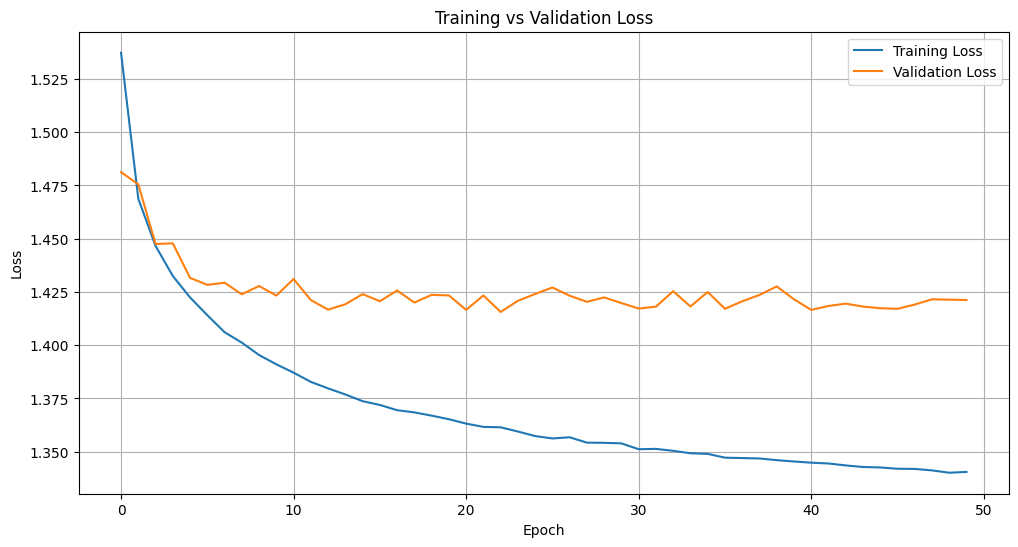

In [30]:
# 1. Plot Accuracy
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot Loss (facoltativo ma utile)
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


## GRID SEARCH

In [ ]:
#!pip install keras-tuner -q



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:

def model_builder(hp):
    inputs = keras.Input(shape=(X_train.shape[1],))
    x = inputs
    
    # 1) Numero di layer e unità per layer
    num_layers = hp.Int("num_layers", 1, 3, default=2)
    for i in range(num_layers):
        units = hp.Choice(f"units_{i}", [64, 128, 256], default=128)
        
        # 2) Regolarizzazione L1/L2
        reg_type = hp.Choice(f"reg_type_{i}", ["none", "l1", "l2"], default="none")
        if reg_type == "l1":
            reg = keras.regularizers.l1(hp.Float(f"l1_{i}", 1e-5, 1e-2, sampling="LOG"))
        elif reg_type == "l2":
            reg = keras.regularizers.l2(hp.Float(f"l2_{i}", 1e-5, 1e-2, sampling="LOG"))
        else:
            reg = None
        
        x = layers.Dense(units, activation="relu",
                         kernel_regularizer=reg)(x)
        
        # 3) Dropout
        dropout_rate = hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1, default=0.0)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)
        
        # 4) BatchNorm (sempre opzionale)
        if hp.Boolean(f"batchnorm_{i}", default=True):
            x = layers.BatchNormalization()(x)
    
    outputs = layers.Dense(len(np.unique(y_train)), activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    
    # 5) Scelta dell'ottimizzatore e dei suoi iperparametri
    optimizer_choice = hp.Choice("optimizer", ["sgd", "adam"], default="adam")
    if optimizer_choice == "sgd":
        # momentum
        momentum = hp.Float("momentum", 0.0, 0.99, step=0.1, default=0.9)
        lr = hp.Float("sgd_lr", 1e-4, 1e-2, sampling="LOG", default=1e-3)
        optimizer = keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
    else:
        # Adam con beta1 come “momentum”
        beta1 = hp.Float("beta1", 0.8, 0.99, step=0.05, default=0.9)
        lr = hp.Float("adam_lr", 1e-5, 1e-2, sampling="LOG", default=1e-3)
        optimizer = keras.optimizers.Adam(learning_rate=lr, beta_1=beta1)
    
    # 6) Compilazione
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Configuriamo il tuner: qui usiamo RandomSearch
tuner = kt.RandomSearch(
    model_builder,
    objective="val_accuracy",
    max_trials=30,            # quanti set di iperparametri provare
    executions_per_trial=2,    # mediamente più robusto
    directory="tuner_dir", 
    project_name="mlp_tuning"
)

# Callback di early stopping
stop_early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# Lancio della ricerca
tuner.search(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[stop_early],
    verbose=2
)

# Recupero del miglior modello
best_model = tuner.get_best_models(num_models=1)[0]

# Valutazione sul test set
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Best test accuracy: {test_acc:.4f}")

# Report degli iperparametri migliori
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for param in best_hp.values.keys():
    print(f"  {param}: {best_hp.get(param)}")


Trial 30 Complete [00h 06m 42s]
val_accuracy: 0.4008001536130905

Best val_accuracy So Far: 0.4178636819124222
Total elapsed time: 03h 10m 45s


/Users/daviderizzello/Documents/UNIPI/Data_Mining/DataMining2/env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best test accuracy: 0.4222
Best hyperparameters:
  num_layers: 3
  units_0: 128
  reg_type_0: none
  dropout_0: 0.0
  batchnorm_0: True
  units_1: 64
  reg_type_1: l2
  dropout_1: 0.1
  batchnorm_1: False
  optimizer: adam
  beta1: 0.8
  adam_lr: 0.0001034585127296602
  l2_0: 0.00011530373913524302
  l1_0: 5.907748619371227e-05
  l2_1: 0.0014245645223308224
  units_2: 64
  reg_type_2: l2
  dropout_2: 0.4
  batchnorm_2: True
  l1_1: 4.5926693208480303e-05
  momentum: 0.5
  sgd_lr: 0.007711862216981024
  l2_2: 0.006784154472050656


In [54]:
# Ricrea il modello con gli hyperparametri ottimali
best_hp = tuner.get_best_hyperparameters(1)[0]
final_model = model_builder(best_hp)

# Allena su tutto X_train (incluso il 20% che prima era validation)
final_model.fit(
    X_train, y_train,
    epochs=100,                  # o un numero più alto
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='loss', 
        patience=5, 
        restore_best_weights=True
    )],
    verbose=2
)

# Salva il modello su disco
final_model.save('best_models/best_mlp_model.h5')


Epoch 1/100
3242/3242 - 6s - 2ms/step - accuracy: 0.2705 - loss: 2.4197
Epoch 2/100
3242/3242 - 3s - 1ms/step - accuracy: 0.3424 - loss: 1.9912
Epoch 3/100
3242/3242 - 3s - 1ms/step - accuracy: 0.3624 - loss: 1.8089
Epoch 4/100
3242/3242 - 4s - 1ms/step - accuracy: 0.3744 - loss: 1.6948
Epoch 5/100
3242/3242 - 7s - 2ms/step - accuracy: 0.3828 - loss: 1.6253
Epoch 6/100
3242/3242 - 3s - 1ms/step - accuracy: 0.3877 - loss: 1.5787
Epoch 7/100
3242/3242 - 3s - 1ms/step - accuracy: 0.3907 - loss: 1.5459
Epoch 8/100
3242/3242 - 3s - 1ms/step - accuracy: 0.3930 - loss: 1.5236
Epoch 9/100
3242/3242 - 3s - 1ms/step - accuracy: 0.3949 - loss: 1.5066
Epoch 10/100
3242/3242 - 3s - 1ms/step - accuracy: 0.3972 - loss: 1.4929
Epoch 11/100
3242/3242 - 5s - 2ms/step - accuracy: 0.3984 - loss: 1.4833
Epoch 12/100
3242/3242 - 4s - 1ms/step - accuracy: 0.4004 - loss: 1.4745
Epoch 13/100
3242/3242 - 4s - 1ms/step - accuracy: 0.4021 - loss: 1.4656
Epoch 14/100
3242/3242 - 4s - 1ms/step - accuracy: 0.4031 - 

In [55]:
# Salva il modello su disco
final_model.save('best_models/best_mlp_model.keras')


811/811 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step
              precision    recall  f1-score   support

           0       0.38      0.12      0.18       911
           1       0.39      0.15      0.22      1615
           2       0.40      0.29      0.33      3761
           3       0.41      0.42      0.41      6804
           4       0.45      0.74      0.56      8363
           5       0.40      0.15      0.21      3761
           6       0.62      0.10      0.18       718

    accuracy                           0.43     25933
   macro avg       0.43      0.28      0.30     25933
weighted avg       0.42      0.43      0.39     25933



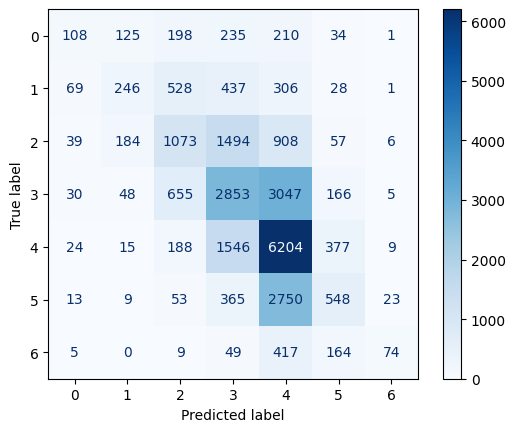

In [58]:

y_pred = final_model.predict(X_test).argmax(axis=1)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')


## BALANCING

In [69]:
#!pip install imbalanced-learn

In [68]:
(y_train.value_counts()*100)/y_train.shape[0]

rating_class
4    32.249108
3    26.237347
5    14.504001
2    14.503037
1     6.224814
0     3.513930
6     2.767762
Name: count, dtype: float64

In [73]:

smote = SMOTE(
    sampling_strategy='auto',  # bilancia tutte le classi al livello della più numerosa
    k_neighbors=5,
    random_state=42
)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("Distribuzione prima:", (y_train.value_counts()*100)/y_train.shape[0])
print("Distribuzione dopo SMOTE:", (y_res.value_counts()*100)/y_res.shape[0])



Distribuzione prima: rating_class
4    32.249108
3    26.237347
5    14.504001
2    14.503037
1     6.224814
0     3.513930
6     2.767762
Name: count, dtype: float64
Distribuzione dopo SMOTE: rating_class
0    14.285714
4    14.285714
3    14.285714
6    14.285714
5    14.285714
2    14.285714
1    14.285714
Name: count, dtype: float64


In [76]:
final_model = model_builder(best_hp)  # usa gli hyperparametri trovati

history = final_model.fit(
    X_res, y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,             # validazione interna
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )],
    verbose=2
)

# 5) Valuta su X_test originale
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy su test set dopo SMOTE: {test_acc:.4f}")

# 6) (Opzionale) Report e confusion matrix
y_pred = final_model.predict(X_test).argmax(axis=1)
print(classification_report(y_test, y_pred))


Epoch 1/50
5855/5855 - 10s - 2ms/step - accuracy: 0.2531 - loss: 2.3538 - val_accuracy: 0.0054 - val_loss: 3.4191
Epoch 2/50
5855/5855 - 7s - 1ms/step - accuracy: 0.3289 - loss: 1.8460 - val_accuracy: 0.0052 - val_loss: 3.4131
Epoch 3/50
5855/5855 - 7s - 1ms/step - accuracy: 0.3632 - loss: 1.6546 - val_accuracy: 0.0081 - val_loss: 3.3272
Epoch 4/50
5855/5855 - 7s - 1ms/step - accuracy: 0.3771 - loss: 1.5690 - val_accuracy: 0.0080 - val_loss: 3.3139
Epoch 5/50
5855/5855 - 7s - 1ms/step - accuracy: 0.3858 - loss: 1.5227 - val_accuracy: 0.0127 - val_loss: 3.2826
Epoch 6/50
5855/5855 - 7s - 1ms/step - accuracy: 0.3944 - loss: 1.4922 - val_accuracy: 0.0124 - val_loss: 3.2535
Epoch 7/50
5855/5855 - 7s - 1ms/step - accuracy: 0.3986 - loss: 1.4726 - val_accuracy: 0.0190 - val_loss: 3.0865
Epoch 8/50
5855/5855 - 7s - 1ms/step - accuracy: 0.4032 - loss: 1.4563 - val_accuracy: 0.0088 - val_loss: 3.2381
Epoch 9/50
5855/5855 - 9s - 2ms/step - accuracy: 0.4089 - loss: 1.4423 - val_accuracy: 0.0137 -

In [77]:
from imblearn.combine import SMOTEENN
resampler = SMOTEENN(random_state=42)
X_res, y_res = resampler.fit_resample(X_train, y_train)


In [78]:
final_model = model_builder(best_hp)  # usa gli hyperparametri trovati

history = final_model.fit(
    X_res, y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,             # validazione interna
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )],
    verbose=2
)

# 5) Valuta su X_test originale
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy su test set dopo SMOTE: {test_acc:.4f}")

# 6) (Opzionale) Report e confusion matrix
y_pred = final_model.predict(X_test).argmax(axis=1)
print(classification_report(y_test, y_pred))


Epoch 1/50
3502/3502 - 8s - 2ms/step - accuracy: 0.3038 - loss: 2.3205 - val_accuracy: 0.0037 - val_loss: 3.0796
Epoch 2/50
3502/3502 - 5s - 2ms/step - accuracy: 0.3897 - loss: 1.8588 - val_accuracy: 0.0028 - val_loss: 2.9080
Epoch 3/50
3502/3502 - 5s - 1ms/step - accuracy: 0.4251 - loss: 1.6538 - val_accuracy: 0.0044 - val_loss: 2.7916
Epoch 4/50
3502/3502 - 4s - 1ms/step - accuracy: 0.4460 - loss: 1.5316 - val_accuracy: 0.0062 - val_loss: 2.6786
Epoch 5/50
3502/3502 - 7s - 2ms/step - accuracy: 0.4606 - loss: 1.4494 - val_accuracy: 0.0146 - val_loss: 2.4716
Epoch 6/50
3502/3502 - 9s - 2ms/step - accuracy: 0.4710 - loss: 1.3957 - val_accuracy: 0.0098 - val_loss: 2.4176
Epoch 7/50
3502/3502 - 5s - 1ms/step - accuracy: 0.4771 - loss: 1.3601 - val_accuracy: 0.0173 - val_loss: 2.3333
Epoch 8/50
3502/3502 - 5s - 1ms/step - accuracy: 0.4860 - loss: 1.3296 - val_accuracy: 0.0626 - val_loss: 2.2890
Epoch 9/50
3502/3502 - 5s - 1ms/step - accuracy: 0.4928 - loss: 1.3052 - val_accuracy: 0.0654 - 

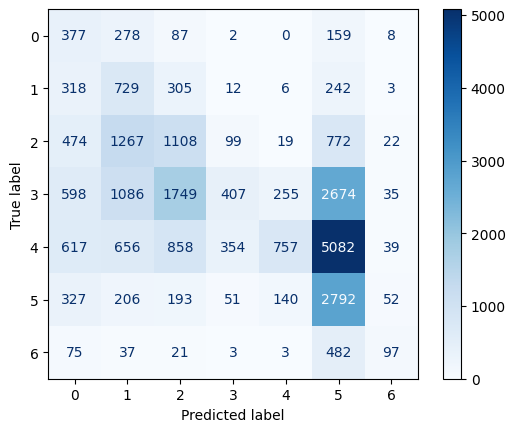

In [81]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues')